# 01 — Data Exploration

**Objective:** Load 6 months of CRMLS sold-property data (Jan–Jun 2024), filter to  
`PropertyType = "Residential"` and `PropertySubType = "SingleFamilyResidence"`,  
and explore distributions of **ClosePrice**, **LivingArea**, **Bedrooms**, **Bathrooms**, and **LotSize**.

## 1 — Imports

In [1]:
import os, glob
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')

## 2 — Load 6 Months of Data

In [2]:
DATA_DIR = os.path.join(os.getcwd(), 'Data')
csv_files = sorted(glob.glob(os.path.join(DATA_DIR, 'CRMLSSold*.csv')))

df_raw = pd.concat(
    [pd.read_csv(f, low_memory=False) for f in csv_files],
    ignore_index=True
)
print(f'Loaded {len(csv_files)} files — {df_raw.shape[0]:,} rows, {df_raw.shape[1]} columns')

Loaded 6 files — 136,614 rows, 82 columns


## 3 — Filter to Residential / Single Family Residence

In [3]:
df = df_raw[
    (df_raw['PropertyType'] == 'Residential') &
    (df_raw['PropertySubType'] == 'SingleFamilyResidence')
].copy()

print(f'After filtering: {df.shape[0]:,} rows  ({df.shape[0]/df_raw.shape[0]*100:.1f}% of raw data)')

After filtering: 68,641 rows  (50.2% of raw data)


## 4 — Quick Overview

In [4]:
cols = ['ClosePrice', 'LivingArea', 'BedroomsTotal',
        'BathroomsTotalInteger', 'LotSizeSquareFeet']

df[cols].describe()

,ClosePrice,LivingArea,BedroomsTotal,BathroomsTotalInteger,LotSizeSquareFeet
count,6.864000e+04,68605.000000,68641.000000,68622.000000,6.748200e+04
mean,1.257151e+06,2027.036120,3.471497,2.608857,1.702650e+05
std,1.330793e+06,1027.672641,0.952916,1.297300,1.001770e+07
min,3.450000e+02,0.000000,0.000000,0.000000,0.000000e+00
25%,6.150000e+05,1367.000000,3.000000,2.000000,5.663000e+03
50%,8.950000e+05,1798.000000,3.000000,2.000000,7.217000e+03
75%,1.460000e+06,2414.000000,4.000000,3.000000,1.025000e+04
max,6.280000e+07,22897.000000,34.000000,175.000000,1.633500e+09


## 5 — Distribution Plots

### 5a — ClosePrice

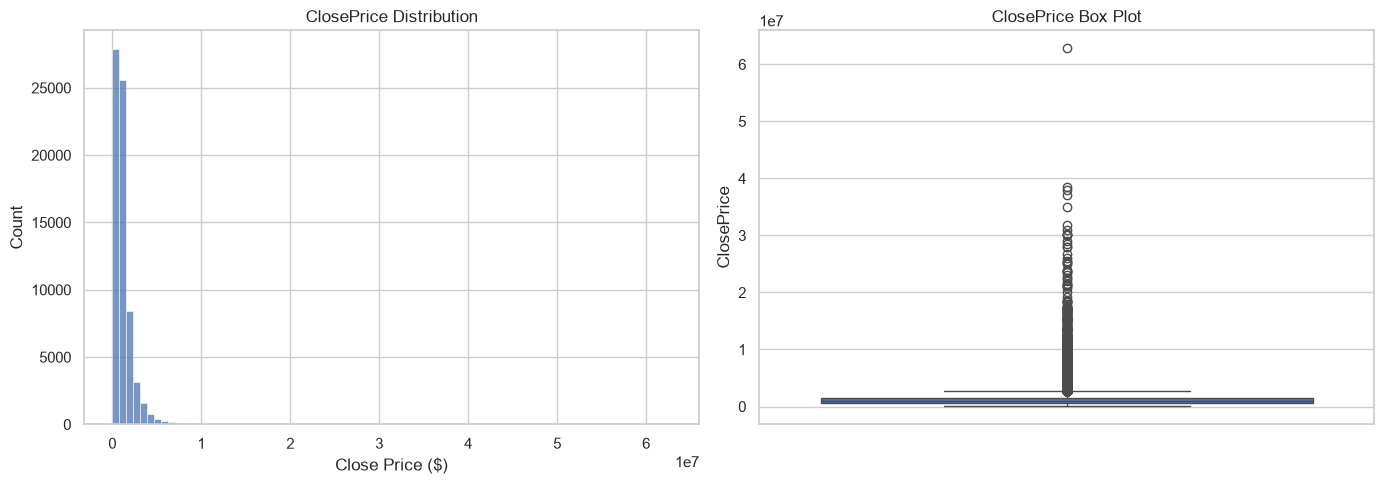

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['ClosePrice'].dropna(), bins=80, ax=axes[0])
axes[0].set_title('ClosePrice Distribution')
axes[0].set_xlabel('Close Price ($)')

sns.boxplot(y=df['ClosePrice'].dropna(), ax=axes[1])
axes[1].set_title('ClosePrice Box Plot')

plt.tight_layout()
plt.show()

### 5b — LivingArea

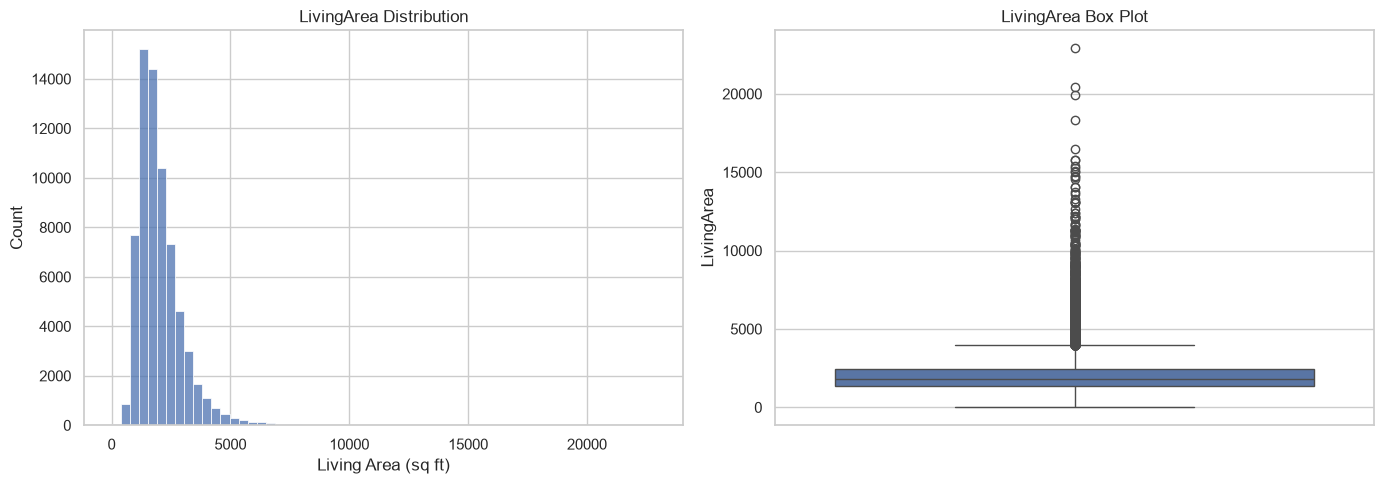

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['LivingArea'].dropna(), bins=60, ax=axes[0])
axes[0].set_title('LivingArea Distribution')
axes[0].set_xlabel('Living Area (sq ft)')

sns.boxplot(y=df['LivingArea'].dropna(), ax=axes[1])
axes[1].set_title('LivingArea Box Plot')

plt.tight_layout()
plt.show()

### 5c — Bedrooms

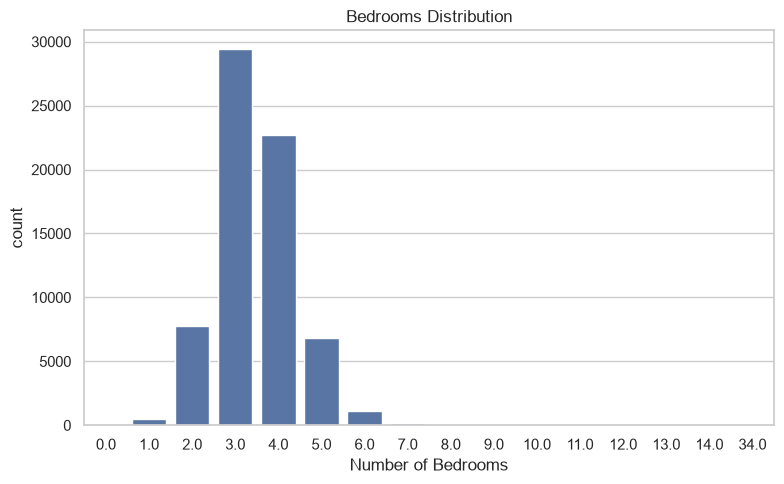

In [7]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.countplot(x='BedroomsTotal', data=df, ax=ax,
              order=sorted(df['BedroomsTotal'].dropna().unique()))
ax.set_title('Bedrooms Distribution')
ax.set_xlabel('Number of Bedrooms')
plt.tight_layout()
plt.show()

### 5d — Bathrooms

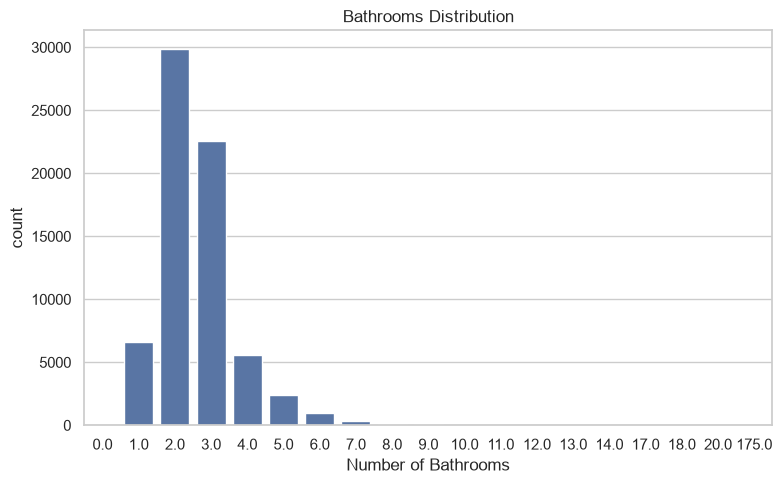

In [8]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.countplot(x='BathroomsTotalInteger', data=df, ax=ax,
              order=sorted(df['BathroomsTotalInteger'].dropna().unique()))
ax.set_title('Bathrooms Distribution')
ax.set_xlabel('Number of Bathrooms')
plt.tight_layout()
plt.show()

### 5e — LotSize

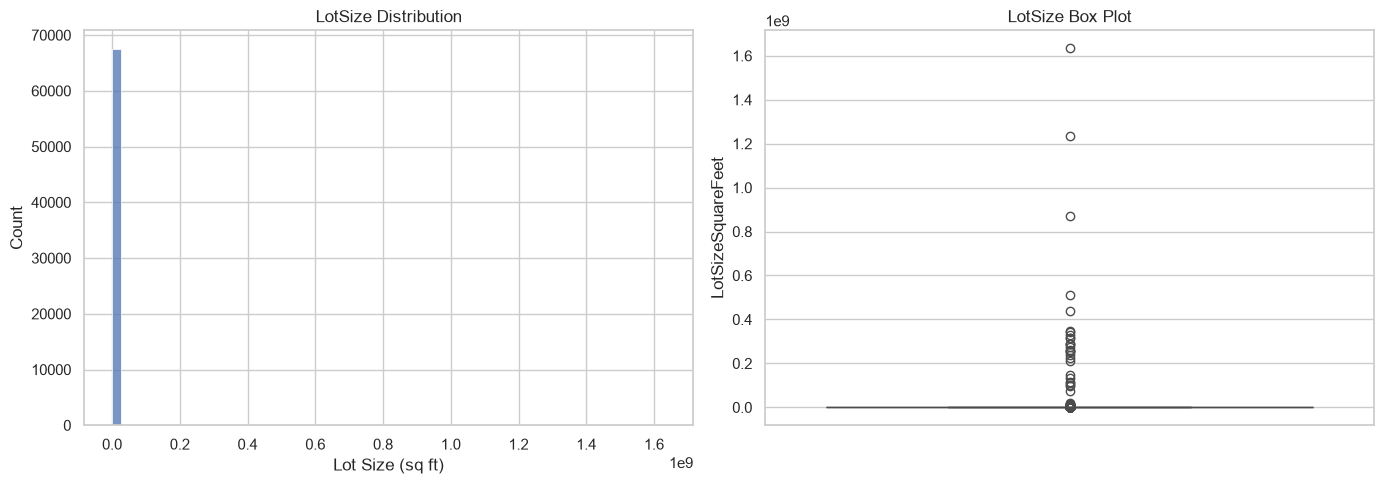

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['LotSizeSquareFeet'].dropna(), bins=60, ax=axes[0])
axes[0].set_title('LotSize Distribution')
axes[0].set_xlabel('Lot Size (sq ft)')

sns.boxplot(y=df['LotSizeSquareFeet'].dropna(), ax=axes[1])
axes[1].set_title('LotSize Box Plot')

plt.tight_layout()
plt.show()